2025-06-11 17:30:40.986091: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-11 17:30:41.017031: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-11 17:30:41.017051: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-11 17:30:41.018037: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-11 17:30:41.023679: I tensorflow/core/platform/cpu_feature_guar

[]


2025-06-11 17:30:42.191930: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_COMPAT_NOT_SUPPORTED_ON_DEVICE: forward compatibility was attempted on non supported HW
2025-06-11 17:30:42.191953: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: balanis
2025-06-11 17:30:42.191956: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: balanis
2025-06-11 17:30:42.192035: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: 550.144.3
2025-06-11 17:30:42.192046: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 550.120.0
2025-06-11 17:30:42.192049: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:244] kernel version 550.120.0 does not match DSO version 550.144.3 -- cannot find working devices in this configuration


data ['LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_200316_001_  5', 'Simulation_01_200428_001_005', 'Simulation_01_200212_001_  7', 'LA_RSPV_150113', 'Simulation_01_210205_001_003', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_200428_001_003', 'LA_LSPV_150113', 'RA_RAFW_140807', 'Simulation_01_200316_001_  3', 'RA_RAA_141230', 'Sinusal_150629', 'Simulation_01_200212_001_  9', 'Simulation_01_200316_001_  1', 'Simulation_01_200428_001_007', 'Simulation_01_200428_001_009', 'Simulation_01_200212_001_  5', 'Simulation_01_210209_001_003', 'LA_RIPV_150121', 'LA_LIPV_150119', 'Simulation_01_200316_001_  9']
models_names ['LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_200316_001_  5', 'Simulation_01_200428_001_005', 'Simulation_01_200212_001_  7', 'LA_RSPV_150113', 'Simulation_01_210205_001_003', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_200428_001_003', 'LA_LSPV_150113', 'RA_RAFW_140807', 'Simulation_01_20

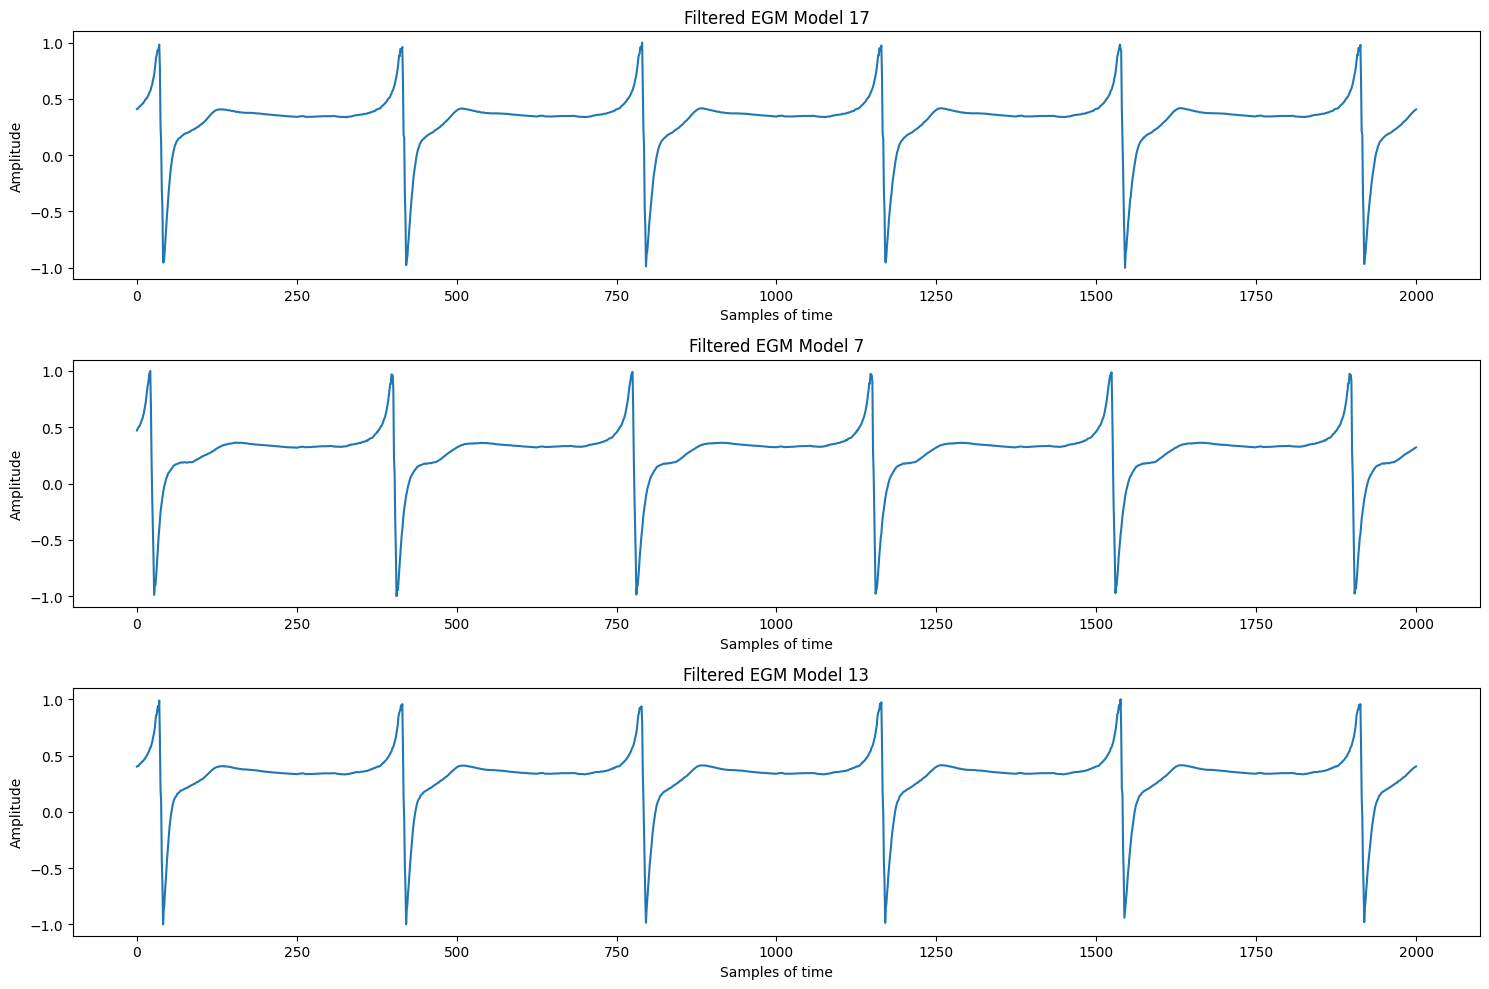

10
Transfer matrices LOADED - var: **transfer_matrices** 
BSPS Models LOADED - var: **bsps_all_models** 
BSPS 64 Models LOADED - var: **bsps_64_all_models** 
210
(3610, 2499)
(3610, 2499)
(64, 2499)
(3970, 2499)
(64, 2499)
(64, 2001)
210
BSPS 64 Models LOADED - var: **bsps_64_all_models** 


In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/home/alumnos/mburgosc/cuda-fake"

import tensorflow as tf

import tensorflow as tf 
import numpy as np
gpus = tf.config.list_physical_devices("GPU")

print(gpus)

import import_data

In [2]:
egms_all_models = import_data.egms_all_models
egms_values = import_data.egms_values
egms_filtered_norm = import_data.egms_filtered_norm
bsps_all_models = import_data.bsps_all_models
bsps_64_all_models = import_data.bsps_64_all_models
transfer_matrices = import_data.transfer_matrices
models_names = import_data.models_names
bsps_64_all_models_names = import_data.bsps_64_all_models_names


In [3]:
models_name_full = bsps_64_all_models_names

print(len(models_name_full))  

filtered_models = []
filtered_models_names = []

for model, name_model in zip(bsps_64_all_models, models_name_full):
    new_model = []

    for node in model:
        original_length = len(node)

        if original_length < 2000:
            continue

        if 2001 <= original_length <= 2500:
            node = node[:2000]
        elif 4001 <= original_length <= 4501:
            node = node[:4000]

        new_model.append(node)

    if len(new_model) > 0:
        filtered_models.append(new_model)
        filtered_models_names.append(name_model)  # Añadimos el nombre del modelo
    bsps_64_filtered_models = filtered_models

print(len(bsps_64_filtered_models))
print(len(filtered_models_names))
print(filtered_models_names)

print(filtered_models_names[140])

210
210
210
['LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200212_001_  7', 'Simulation_01_200212_001_  7', 'Simulation_01_200212_001_  7', 'Simulation_01_200212_001_  7',

In [4]:
import pandas as pd

# Lee CSV de anotaciones
csv_df = pd.read_csv('annotations.csv', header=None)
csv_split = csv_df[0].str.split(';', expand=True)
csv_names = csv_split[0].tolist()
csv_labels = csv_split[1].astype(int).tolist()

# Mapea nombres a etiquetas binarias
name_to_label = {}
for name, label in zip(csv_names, csv_labels):
    if label == 4:
        name_to_label[name] = 0  # Sinusal
    elif label == 3:
        name_to_label[name] = 1  # AF

# Genera lista de etiquetas para cada modelo
filtered_labels = [name_to_label[name] for name in filtered_models_names]
print(filtered_labels)  
print(len(filtered_labels))

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
210


In [5]:
from collections import OrderedDict
import random
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
import numpy as np

modelos_unicos = list(OrderedDict.fromkeys(filtered_models_names)) # NOMBRES DE LOS 21 MODELOS UNICOS
print((modelos_unicos)) 


model_labels_dict = {}                                             # DICCIONARIO CON NOMBRES DE MODELOS Y SUS ETIQUETAS
for name, label in zip(filtered_models_names, filtered_labels):
    if name not in model_labels_dict:
        model_labels_dict[name] = label
print(model_labels_dict)
print(len(model_labels_dict))  


model_to_indices = {m: [] for m in modelos_unicos}  # DICCIONARIO CON NOMBRES DE MODELOS Y SUS INDICES EN filtered_models_names
for i, name in enumerate(filtered_models_names):
    if name in modelos_unicos:
        model_to_indices[name].append(i)
print(f"Índices de modelos: {model_to_indices}")


# DIVIDIR MODELOS UNICOS EN TRAIN Y TEST
train_models, test_models = train_test_split(modelos_unicos, test_size=0.3, random_state=42)

print("train and test models:")
print(train_models)
print(test_models)


# INDICES DE LOS MODELOS EN EL CONJUNTO DE MODELOS
train_indices = [i for model in train_models for i in model_to_indices[model]]
test_indices = [i for model in test_models for i in model_to_indices[model]]
print("train and test indices:")
print(train_indices)
print(test_indices)


X_train, y_train, groups_train = [], [], []
X_test, y_test, groups_test = [], [], []

# PARA DIVIDIR EN SEGMENTOS LOS MODELOS 
def process_indices(indices, target_X, target_y, target_g):
    for idx in indices:
        model_name = filtered_models_names[idx]
        label = model_labels_dict[model_name]
        model_data = np.array(filtered_models[idx])

        if model_data.shape[1] % 500 != 0:
            print(f"Modelo con longitud inesperada: {model_data.shape} - se omite")
            continue

        num_segments = model_data.shape[1] // 500
        segments = [model_data[:, j*500:(j+1)*500] for j in range(num_segments)]

        target_X.extend(segments)
        target_y.extend([label] * len(segments))
        target_g.extend([model_name] * len(segments))

process_indices(train_indices, X_train, y_train, groups_train)
process_indices(test_indices, X_test, y_test, groups_test)


X_train = np.array(X_train)
y_train = np.array(y_train)
groups_train = np.array(groups_train)

X_test = np.array(X_test)
y_test = np.array(y_test)
groups_test = np.array(groups_test)


print(f"Distribución train: {Counter(y_train)}")
print(f"Distribución test: {Counter(y_test)}")
print(f"Shapes: X_train={X_train.shape}, X_test={X_test.shape}")


print(Counter(y_train))
print(f"Datos de entrenamiento: {X_train.shape}, etiquetas: {y_train.shape}, grupos: {groups_train.shape}")
print(f"Datos de prueba: {X_test.shape}, etiquetas: {y_test.shape}, grupos: {groups_test.shape}")


print(y_train)
print(list(OrderedDict.fromkeys((groups_train))))
print(groups_train)

print(Counter(y_test))


['LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  5', 'Simulation_01_200428_001_005', 'Simulation_01_200212_001_  7', 'LA_RSPV_150113', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_200428_001_003', 'LA_LSPV_150113', 'RA_RAFW_140807', 'Simulation_01_200316_001_  3', 'RA_RAA_141230', 'Sinusal_150629', 'Simulation_01_200212_001_  9', 'Simulation_01_200316_001_  1', 'Simulation_01_200428_001_007', 'Simulation_01_200428_001_009', 'Simulation_01_200212_001_  5', 'LA_RIPV_150121', 'LA_LIPV_150119', 'Simulation_01_200316_001_  9']
{'LA_RSPV_CAF_150115': 1, 'Simulation_01_200316_001_  5': 0, 'Simulation_01_200428_001_005': 0, 'Simulation_01_200212_001_  7': 0, 'LA_RSPV_150113': 1, 'Simulation_01_200212_001_  1': 0, 'LA_LSPV_150203': 1, 'Simulation_01_200428_001_003': 0, 'LA_LSPV_150113': 1, 'RA_RAFW_140807': 1, 'Simulation_01_200316_001_  3': 0, 'RA_RAA_141230': 1, 'Sinusal_150629': 0, 'Simulation_01_200212_001_  9': 0, 'Simulation_01_200316_001_  1': 0, 'Simulation_01_2004


#
Dibujar las 64 señales de un modelo:

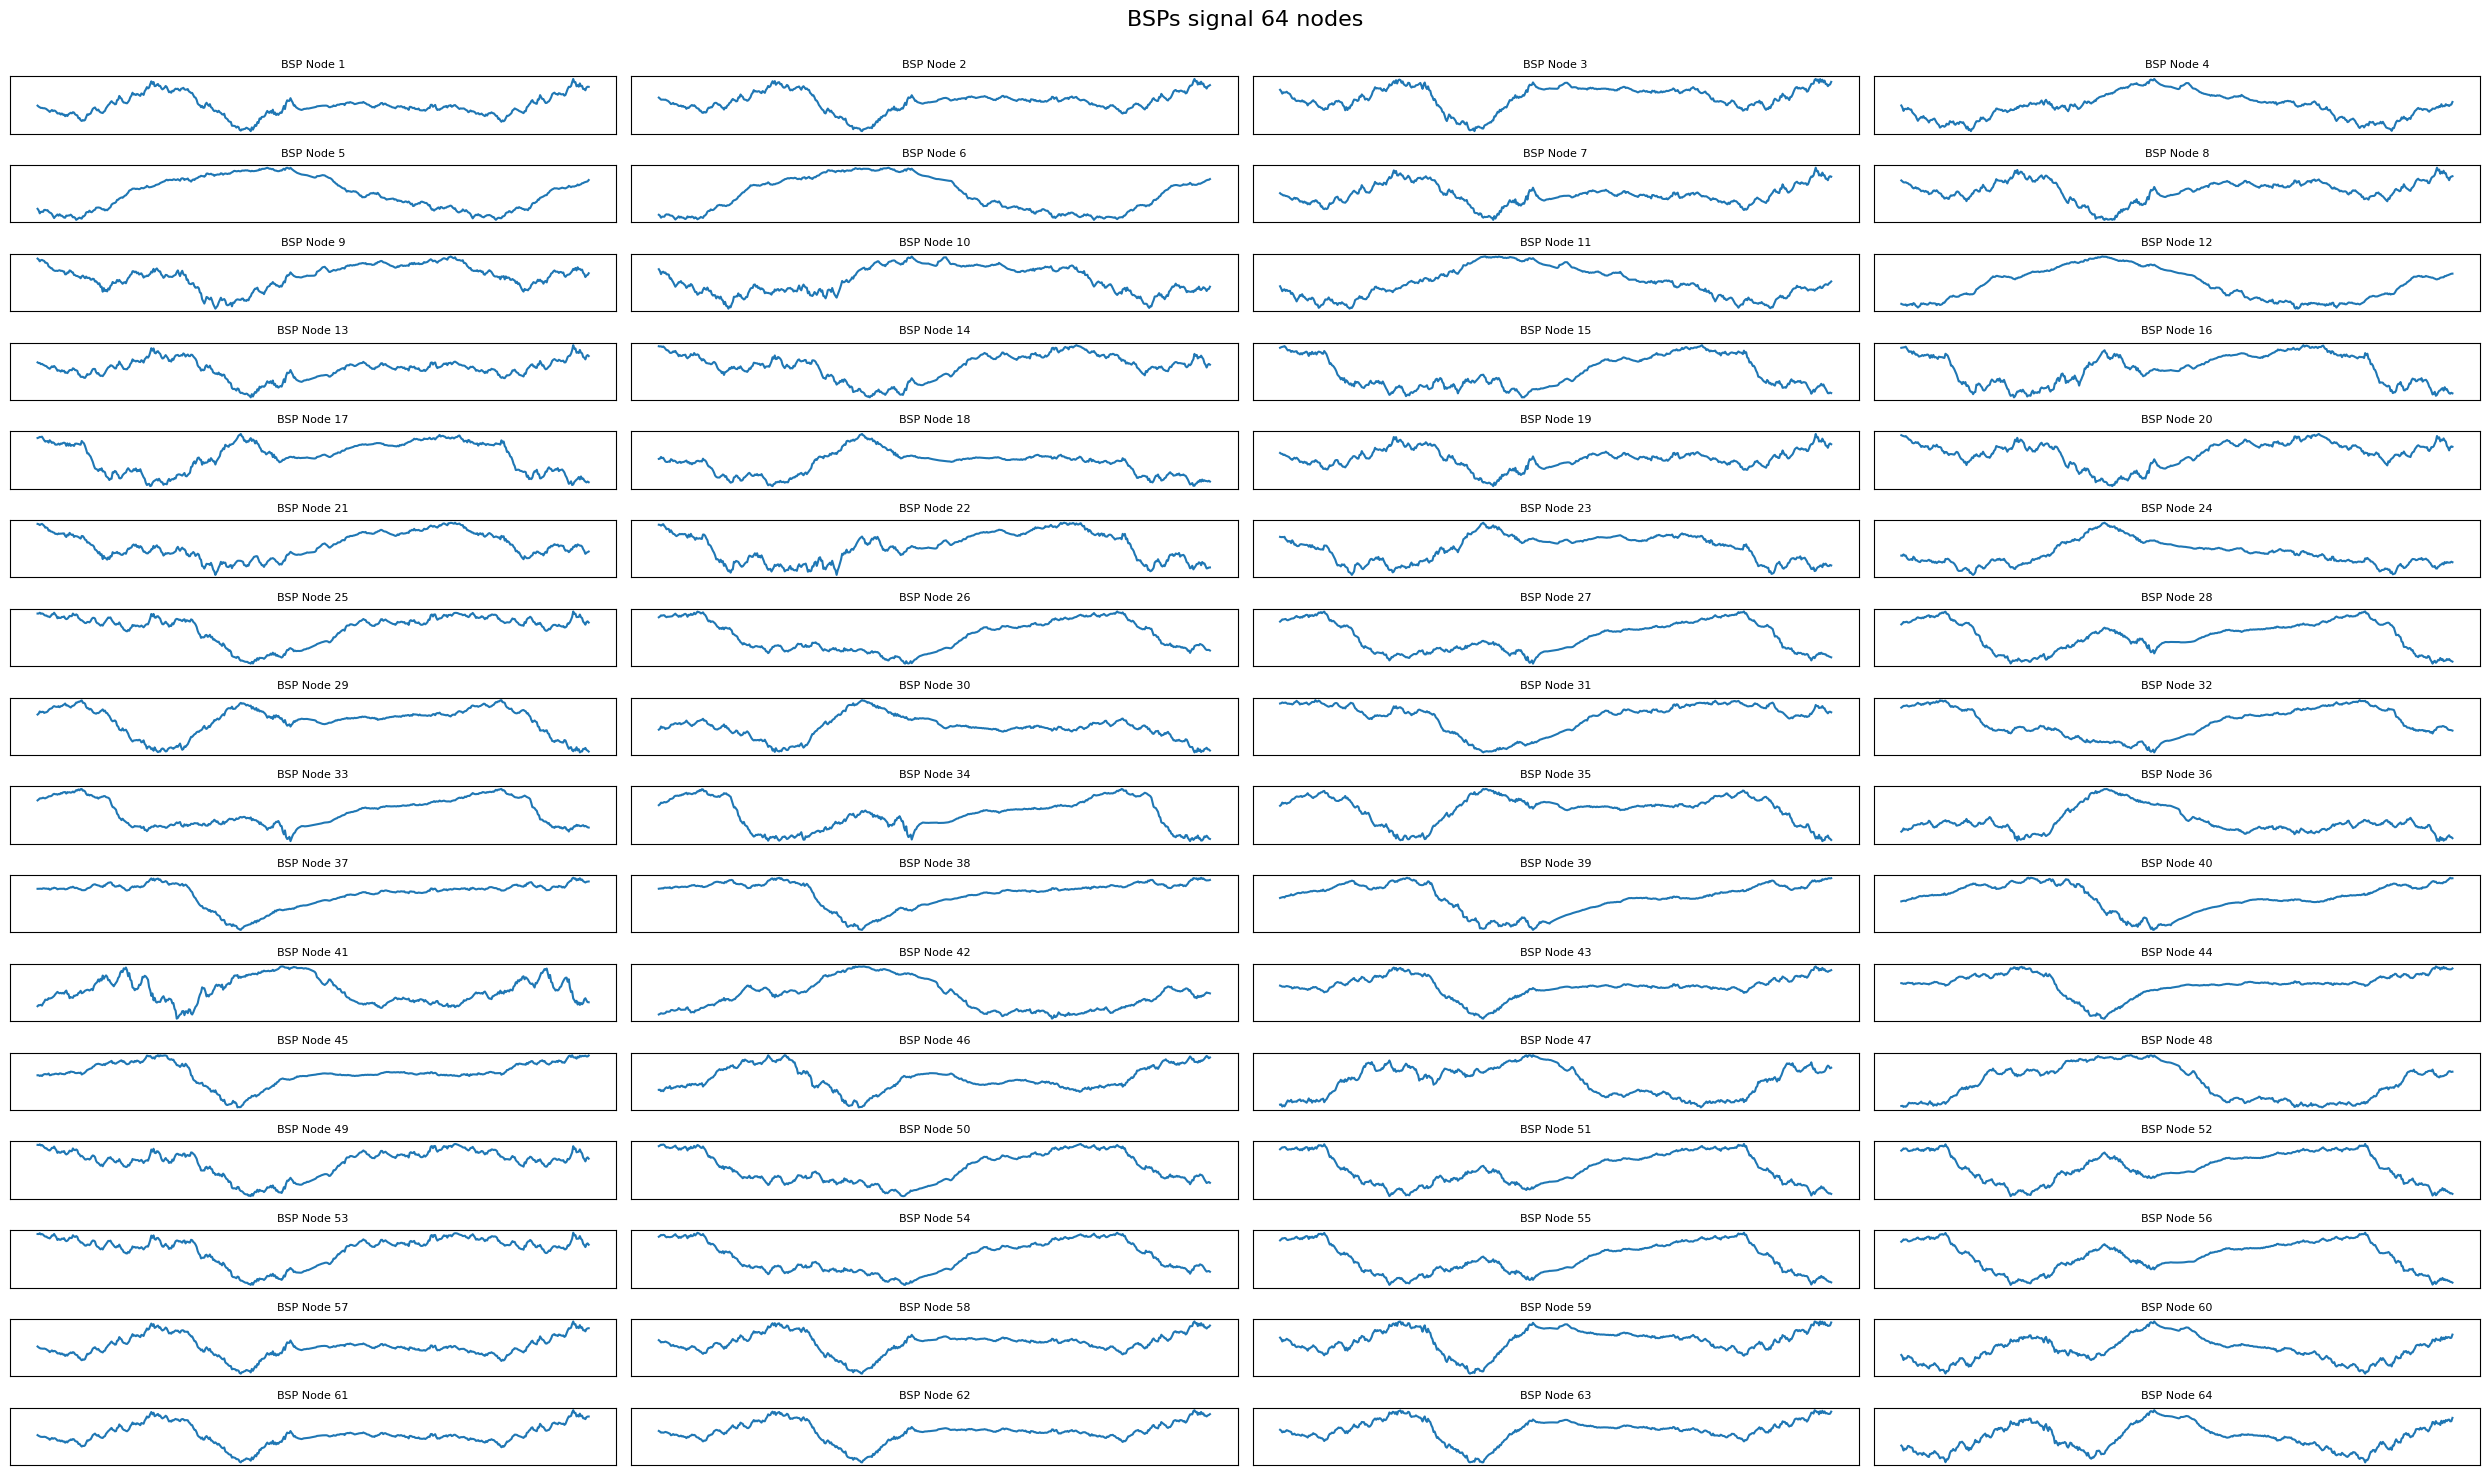

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(16, 4, figsize=(25, 15))  # Adjusted to 32 rows x 2 columns
fig.suptitle('BSPs signal 64 nodes', fontsize=16)

# Flatten axes for easier iteration (since we have 64 subplots)
axes = axes.flatten()

# Plot each of the 64 signals
for i in range(64):
    ax = axes[i]
    ax.plot(X_train[20][i])  # Plot the i-th node's signal
    ax.set_title(f'BSP Node {i+1}', fontsize=8)
    ax.set_xticks([])  # Hide x-ticks for clarity
    ax.set_yticks([])  # Hide y-ticks for clarity
    ax.grid(False)  # Disable grid for cleaner look
# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

(64, 500)


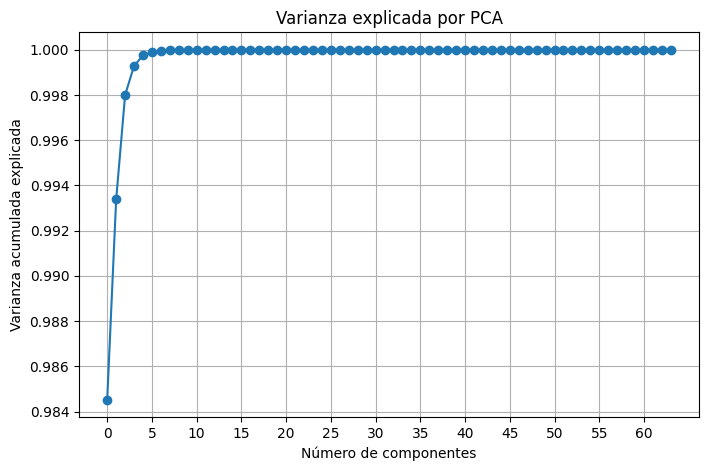

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

model = X_train[2]  # Un modelo: shape (64 nodos, 1000 muestras)
print(model.shape)
pca = PCA()
pca.fit(model)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance), marker='o')

# Personalizar el eje x para mostrar más marcas
plt.xticks(np.arange(0, len(explained_variance), step=5))  # Ajustar el paso según lo necesites

plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada explicada')
plt.title('Varianza explicada por PCA')
plt.grid(True)
plt.show()


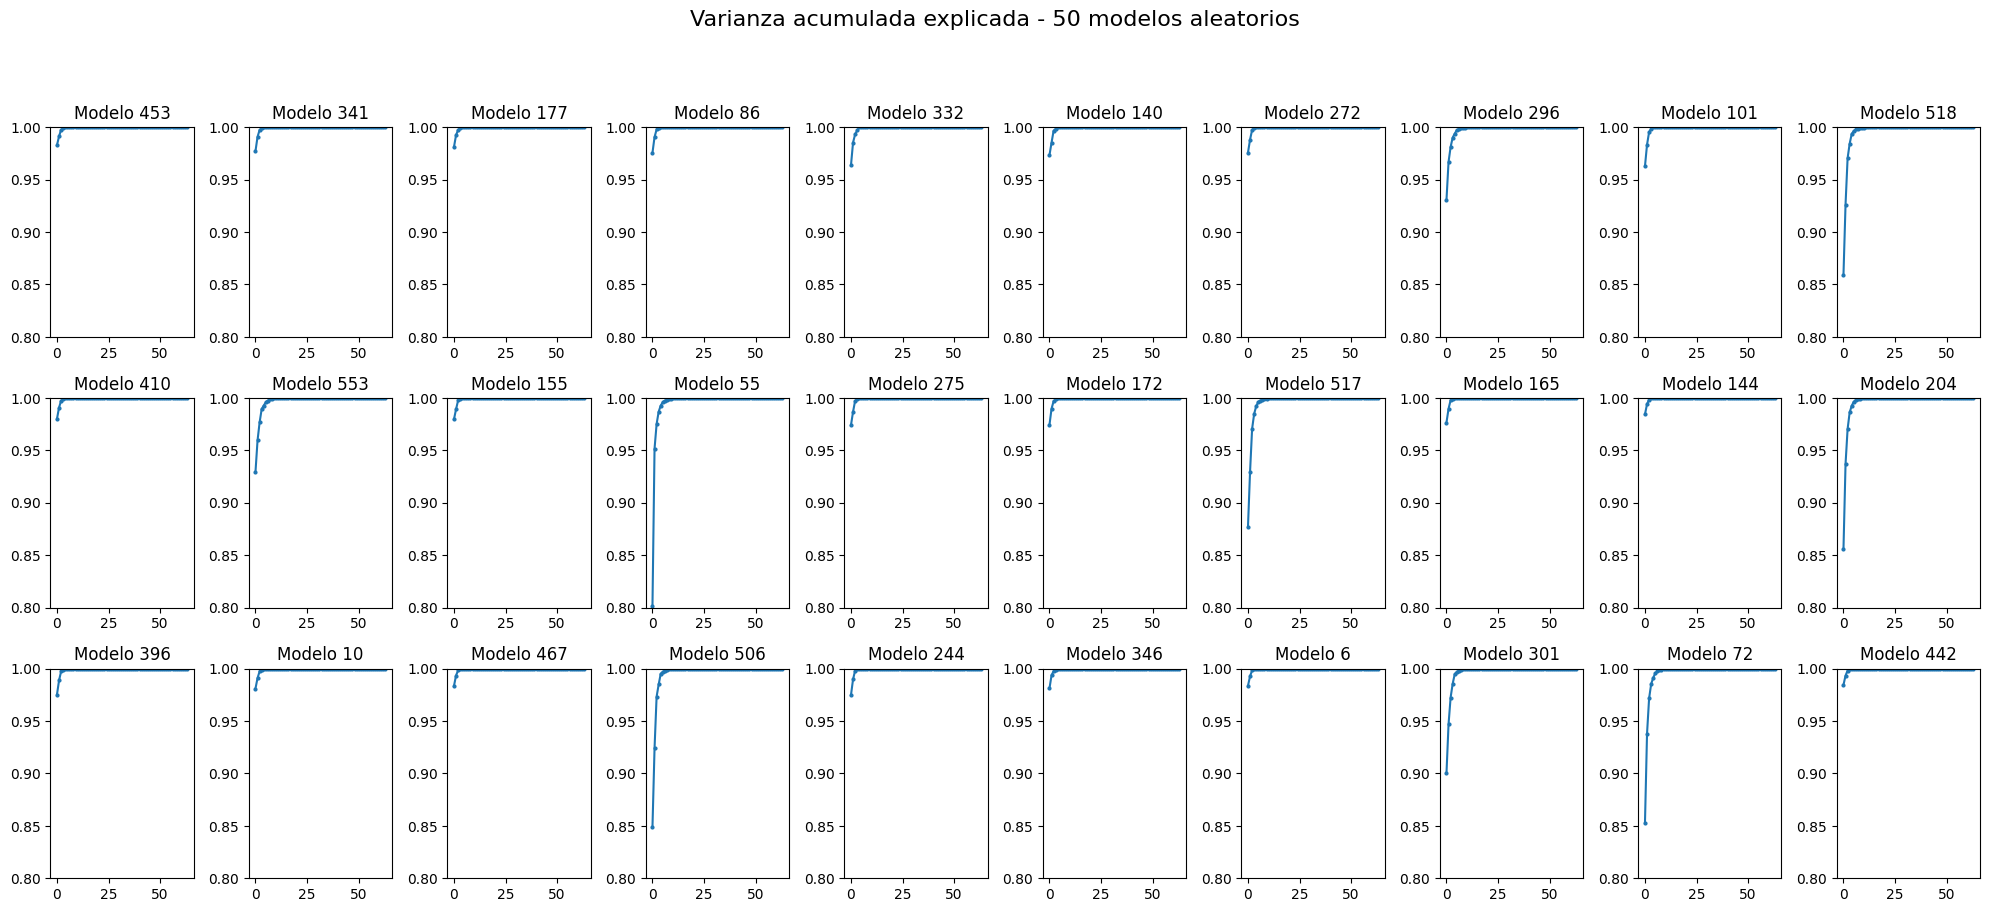

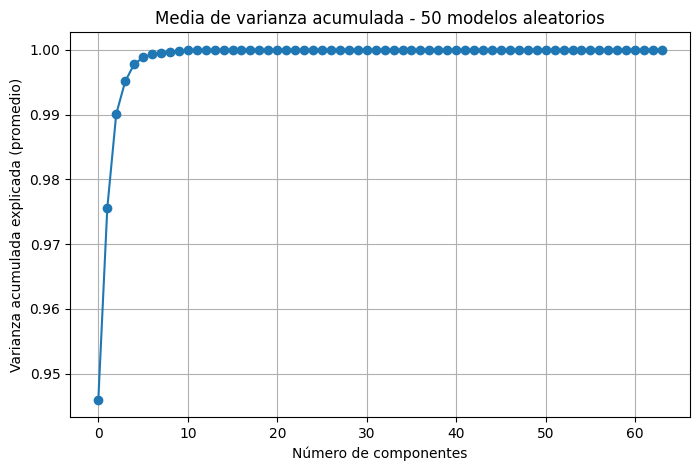

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Suponemos que X_train tiene shape (560, 64, 1000)
num_models = 30
total_models = X_train.shape[0]

# Seleccionamos 50 índices aleatorios sin repetición
np.random.seed(42)  # Para reproducibilidad
random_indices = np.random.choice(total_models, size=num_models, replace=False)

all_cum_var = []

plt.figure(figsize=(20, 15))

for i, idx in enumerate(random_indices):
    model = X_train[idx]  # Shape: (64 nodos, 1000 muestras)
    pca = PCA()
    pca.fit(model)
    explained_variance = pca.explained_variance_ratio_
    cum_var = np.cumsum(explained_variance)
    all_cum_var.append(cum_var)

    plt.subplot(5, 10, i + 1)
    plt.plot(cum_var, marker='o', markersize=2)
    plt.title(f'Modelo {idx}')
    plt.ylim(0.8, 1)

plt.suptitle('Varianza acumulada explicada - 50 modelos aleatorios', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Calcular promedio de la varianza acumulada
mean_cum_var = np.mean(all_cum_var, axis=0)

# Graficar la media
plt.figure(figsize=(8, 5))
plt.plot(mean_cum_var, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada explicada (promedio)')
plt.title('Media de varianza acumulada - 50 modelos aleatorios')
plt.grid(True)
plt.show()


In [8]:
from sklearn.decomposition import PCA

# APLICAR PCA A CADA MODELO
n_components = 3
X_train_pca = []
X_test_pca = []


for model in X_train:
    model_T = model.T  # Transponer para que las muestras sean filas
    pca = PCA(n_components=n_components)
    model_pca = pca.fit_transform(model_T)  # (1000, 2)

    # Si quieres devolverlo como (64, 2) puedes transponer de nuevo
    model_pca = model_pca.T  # (2, 1000)
    X_train_pca.append(model_pca)

for model in X_test:
    model_T = model.T  # Transponer para que las muestras sean filas
    pca = PCA(n_components=n_components)
    model_pca = pca.fit_transform(model_T)  # (1000, 2)

    # Si quieres devolverlo como (64, 2) puedes transponer de nuevo
    model_pca = model_pca.T  # (2, 1000)
    X_test_pca.append(model_pca)




print(f"✅ PCA aplicado por modelo. Ejemplo dimensiones: {np.array(X_train_pca).shape} (3 componentes x 500 muestras)")

✅ PCA aplicado por modelo. Ejemplo dimensiones: (560, 3, 500) (3 componentes x 500 muestras)


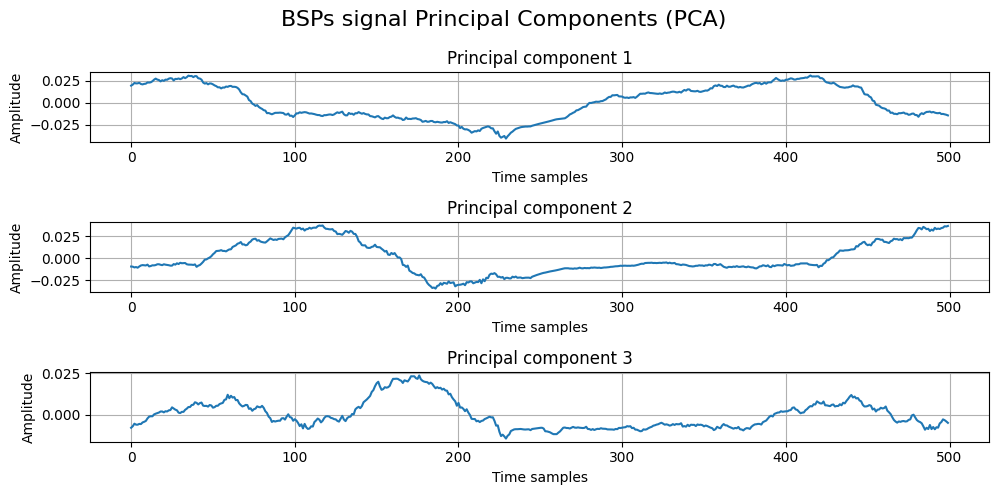

In [10]:
import matplotlib.pyplot as plt


sample = X_train_pca[20]
fig, axes = plt.subplots(3, 1, figsize=(10, 5))
fig.suptitle('BSPs signal Principal Components (PCA)', fontsize=16)
for i in range(3):
    axes[i].plot((sample[i]))
    axes[i].set_title(f'Principal component {i+1}')
    axes[i].set_xlabel('Time samples')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [11]:
from kymatio import Scattering1D
 
# APLICAR SCATTERING A CADA MODELO
J = 4
Q = (16,1)

ws_coeff_all_train_mods = []  
ws_coeff_all_test_mods = []  

for model in X_train_pca:
    model_coeffs = []  
    
    for j in range(len(model)):
        signal = np.array(model[j])  
        len_signal = len(signal)
        
        scattering = Scattering1D(J=J, shape=(len_signal,), Q=Q)
        Sx = scattering(signal)  
        model_coeffs.append(Sx)  
    ws_coeff_all_train_mods.append(np.stack(model_coeffs))


for model in X_test_pca:
    model_coeffs = []  
    
    for j in range(len(model)):
        signal = np.array(model[j])  
        len_signal = len(signal)
        
        scattering = Scattering1D(J=J, shape=(len_signal,), Q=Q)
        Sx = scattering(signal)  
        model_coeffs.append(Sx)  
    ws_coeff_all_test_mods.append(np.stack(model_coeffs))

print(f"✅ Scattering aplicado por modelo. Ejemplo dimensiones: {ws_coeff_all_train_mods[0].shape} (64 nodos, 3 componentes, 500 muestras)")



✅ Scattering aplicado por modelo. Ejemplo dimensiones: (3, 74, 31) (64 nodos, 3 componentes, 500 muestras)


In [12]:
ws_coeff_all_test_mods = np.array(ws_coeff_all_test_mods)
ws_coeff_all_train_mods = np.array(ws_coeff_all_train_mods)

X_train_final = ws_coeff_all_train_mods.reshape(ws_coeff_all_train_mods.shape[0], -1)
X_test_final = ws_coeff_all_test_mods.reshape(ws_coeff_all_test_mods.shape[0], -1)
print(X_train_final.shape, X_test_final.shape)

print(list(OrderedDict.fromkeys((groups_test))))
print(y_test)

Counter(y_test)

(560, 6882) (280, 6882)
['LA_RSPV_CAF_150115', 'Simulation_01_200212_001_  5', 'Simulation_01_200428_001_007', 'Simulation_01_200316_001_  5', 'LA_LSPV_150113', 'Simulation_01_200212_001_  1', 'RA_RAA_141230']
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


Counter({0: 160, 1: 120})

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, log_loss


print(Counter(y_train))
print(Counter(y_test))

rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)

rf.fit(X_train_final, y_train)

# Predecir y evaluar en test
y_pred = rf.predict(X_test_final)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", cm)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)

y_proba = rf.predict_proba(X_test_final)[:, 1]
print("AUC-ROC:", roc_auc_score(y_test, y_proba))
print("Log loss:", log_loss(y_test, y_proba))

Counter({0: 360, 1: 200})
Counter({0: 160, 1: 120})
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       160
           1       1.00      1.00      1.00       120

    accuracy                           1.00       280
   macro avg       1.00      1.00      1.00       280
weighted avg       1.00      1.00      1.00       280

Accuracy: 1.0
Confusion Matrix:
 [[160   0]
 [  0 120]]
Sensitivity (Recall): 1.0
Specificity: 1.0
AUC-ROC: 1.0
Log loss: 0.020894297183233983


In [23]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Distribución de búsqueda
param_dist = {
    'max_depth': [None] + list(range(10, 50, 10)),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'bootstrap': [True, False], 
    'max_features': ['sqrt', 'log2', None],
}

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=50, cv=5, random_state=42,
                                   n_jobs=-1, verbose=2, scoring='accuracy')

random_search.fit(X_train_final, y_train)

# Mejor modelo
best_model = random_search.best_estimator_
print("Mejores hiperparámetros:", random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=3; total time=   0.3s
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=3; total time=   0.3s
[CV] END bootstrap=False, max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=3; total time=   0.3s
[CV] END bootstrap=False, max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=3; total time=   0.3s
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=3; total time=   0.3s
[CV] END bootstrap=True, max_depth=40, max_features=log2, min_samples_leaf=3, min_samples_split=6; total time=   0.3s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=7; total time=   0.3s
[CV] END bootstrap=True, max_depth=40, max_features=log2, min_samples_leaf=3, min_samples_split=6; total t

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, log_loss


print(Counter(y_train))
print(Counter(y_test))

rf = RandomForestClassifier(n_estimators=1000, max_depth=30, min_samples_leaf=3, min_samples_split=9, bootstrap=True, max_features='sqrt', random_state=42)

rf.fit(X_train_final, y_train)

# Predecir y evaluar en test
y_pred = rf.predict(X_test_final)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", cm)
print("Sensitivity (Recall):", sensitivity)
print("Specificity:", specificity)

y_proba = rf.predict_proba(X_test_final)[:, 1]
print("AUC-ROC:", roc_auc_score(y_test, y_proba))
print("Log loss:", log_loss(y_test, y_proba))

Counter({0: 360, 1: 200})
Counter({0: 160, 1: 120})
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       160
           1       1.00      1.00      1.00       120

    accuracy                           1.00       280
   macro avg       1.00      1.00      1.00       280
weighted avg       1.00      1.00      1.00       280

Accuracy: 1.0
Confusion Matrix:
 [[160   0]
 [  0 120]]
Sensitivity (Recall): 1.0
Specificity: 1.0
AUC-ROC: 1.0
Log loss: 0.025100595808181886


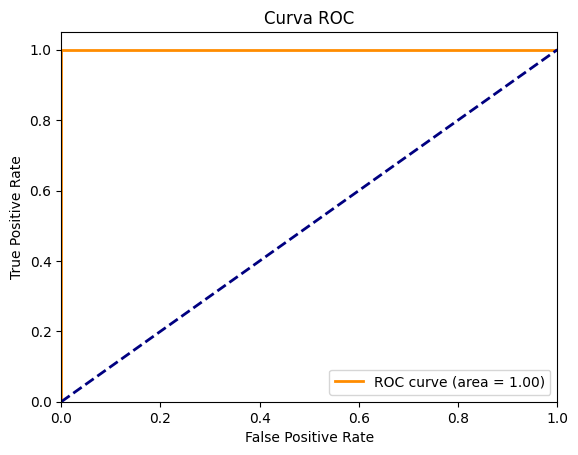

In [27]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtener las probabilidades de las predicciones
y_prob = rf.predict_proba(X_test_final)[:, 1]

# Calcular las curvas ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

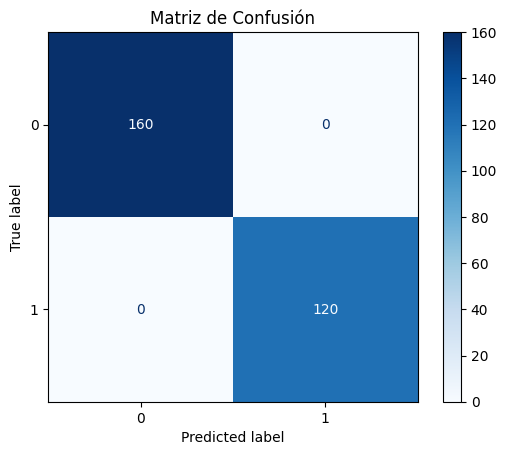

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)  # Puedes cambiar el color si quieres
plt.title("Matriz de Confusión")
plt.show()
